In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.feature_selection import SelectKBest, f_classif

In [2]:
df = pd.read_csv('heart.csv')
df.sample(5)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
594,64,1,0,145,212,0,0,132,0,2.0,1,2,1,0
847,61,1,0,138,166,0,0,125,1,3.6,1,1,2,0
821,62,0,0,140,268,0,0,160,0,3.6,0,2,2,0
165,59,1,0,170,326,0,0,140,1,3.4,0,0,3,0
917,47,1,2,130,253,0,1,179,0,0.0,2,0,2,1


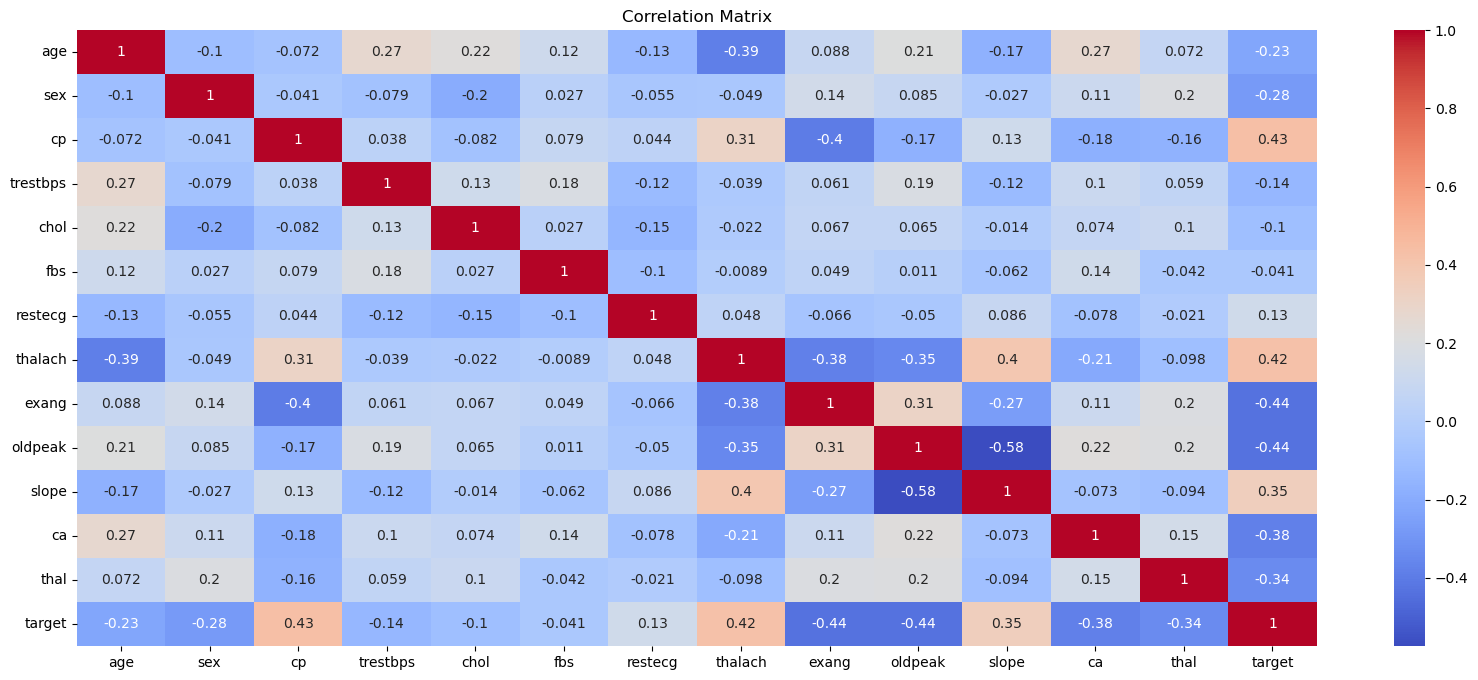

In [3]:
correlation_matrix = df.corr()

plt.figure(figsize=(20,8))
sns.heatmap(correlation_matrix, annot= True, cmap = 'coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [4]:
X = df.drop('target', axis=1)
y = df["target"]

selector = SelectKBest(score_func= f_classif, k = 4)
X_new = selector.fit_transform(X, y)
X_new

array([[  0. , 168. ,   0. ,   1. ],
       [  0. , 155. ,   1. ,   3.1],
       [  0. , 125. ,   1. ,   2.6],
       ...,
       [  0. , 118. ,   1. ,   1. ],
       [  0. , 159. ,   0. ,   0. ],
       [  0. , 113. ,   0. ,   1.4]])

In [5]:
selected_feature_indices = selector.get_support(indices=True)
selected_feature_names = df.columns[selected_feature_indices]
selected_feature_names

Index(['cp', 'thalach', 'exang', 'oldpeak'], dtype='object')

In [6]:
scalar = StandardScaler()
X_scaled = scalar.fit_transform(X_new)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, random_state=42, test_size=0.2)

In [8]:
LR = LogisticRegression()
LR.fit(X_train, y_train)

LogisticRegression()

In [9]:
y_train_pred = LR.predict(X_train)
y_test_pred = LR.predict(X_test)

In [10]:
cm_train = confusion_matrix(y_train, y_train_pred)
cm_test = confusion_matrix(y_test, y_test_pred)


Text(518.4494949494949, 0.5, 'Actual')

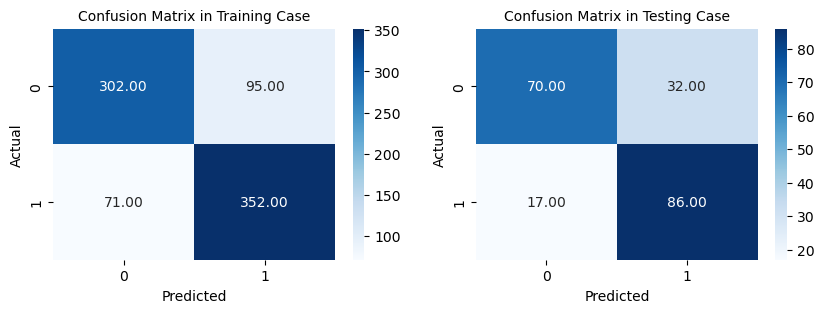

In [11]:
plt.figure(figsize=(10,3))

plt.subplot(121)
sns.heatmap(cm_train, annot=True, cmap= 'Blues', fmt='0.2f')
plt.title("Confusion Matrix in Training Case", fontsize = 10)
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(122)
sns.heatmap(cm_test, annot=True, cmap= 'Blues', fmt='0.2f')
plt.title("Confusion Matrix in Testing Case", fontsize = 10)
plt.xlabel("Predicted")
plt.ylabel("Actual")

In [12]:
accuracy_train = accuracy_score(y_train, y_train_pred)
accuracy_test = accuracy_score(y_test, y_test_pred)
precision_train = precision_score(y_train, y_train_pred)
precision_test = precision_score(y_test, y_test_pred)
recall_train = recall_score(y_train, y_train_pred)
recall_test = recall_score(y_test, y_test_pred)
f1_train = f1_score(y_train, y_train_pred)
f1_test = f1_score(y_test, y_test_pred)

print(f'Accuracy Train: {accuracy_train: .2f}')
print(f'Accuracy Test: {accuracy_test: .2f}')
print(f'precision_train: {precision_train: .2f}')
print(f'precision_test: {precision_test: .2f}')
print(f'recall_train: {recall_train: .2f}')
print(f'recall_test: {recall_test: .2f}')
print(f'f1_train: {f1_train: .2f}')
print(f'f1_test: {f1_test: .2f}')

Accuracy Train:  0.80
Accuracy Test:  0.76
precision_train:  0.79
precision_test:  0.73
recall_train:  0.83
recall_test:  0.83
f1_train:  0.81
f1_test:  0.78


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, LinearSVC
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, learning_curve, validation_curve
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")

In [14]:
dataset_name = "wine" # @param ["iris","wine","breast_cancer","digits"]

def load_dataset(name):
    if name == "iris":
        data = datasets.load_iris()
    elif name == "wine":
        data = datasets.load_wine()
    elif name == "breast_cancer":
        data = datasets.load_breast_cancer()
    elif name == "digits":
        data = datasets.load_digits()
    else:
        raise ValueError("Unknown dataset")
    X = data.data
    y = data.target
    feature_names = getattr(data, "feature_names", [f"f{i}" for i in range(X.shape[1])])
    target_names = getattr(data, "target_names", [str(i) for i in np.unique(y)])
    return X, y, feature_names, target_names

X, y, feature_names, target_names = load_dataset(dataset_name)
print(f"Dataset: {dataset_name} | Samples: {X.shape[0]} | Features: {X.shape[1]} | Classes: {len(np.unique(y))}")


Dataset: wine | Samples: 178 | Features: 13 | Classes: 3


In [15]:
test_size = 0.25  #@param {type:"slider", min:0.1, max:0.5, step:0.05}
random_state = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=random_state, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (133, 13), Test: (45, 13)
